# Netflix Data Analysis Assignment

This notebook contains TODO tasks for you to complete using the Netflix dataset. Follow the instructions in each section, fill in the code cells, and run them to analyze the data.

**Dataset:** `processed_data/netflix_final.csv`

**Objectives:**
- Load and explore the dataset
- Clean and preprocess the data
- Perform basic analysis and statistics
- Create visualizations
- Draw insights and conclusions


## Section 1: Import Required Libraries

Import the necessary libraries for data manipulation, analysis, and visualization.


In [12]:
# TODO: Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8')


In [13]:
#!python3 -m pip install matplotlib seaborn

## Section 2: Load the Netflix Dataset

Load the `netflix_final.csv` file from the `processed_data` directory and display the first few rows to understand the data structure.


In [14]:
# TODO: Load the Netflix dataset

netflix_df = pd.read_csv('/Users/shivani/Downloads/netflix_etl_project/data/processed_data/netflix_final.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
netflix_df.head()


First 5 rows of the dataset:


,title,type,release_year,country,rating,duration,imdb,rotten_tomatoes,target_age_bracket
0,#Alive,Movie,2020,South Korea,TV-MA,99 min,NaN,NaN,NaN
1,#AnneFrank - Parallel Stories,Movie,2019,Italy,TV-14,95 min,NaN,NaN,NaN
2,#blackAF,TV Show,2020,United States,TV-MA,1 Season,6.6,NaN,18
3,#cats_the_mewvie,Movie,2020,Canada,TV-14,90 min,5.2,NaN,16
4,#FriendButMarried,Movie,2018,Indonesia,TV-G,102 min,NaN,NaN,NaN


## Section 3: Explore the Dataset Structure

TODO: Examine the dataset's shape, columns, data types, and check for missing values. Answer the following questions:
- How many rows and columns does the dataset have?
- What are the column names and their data types?
- Are there any missing values? If so, in which columns?
- What are the unique values in categorical columns like 'type'?


In [15]:
# TODO: Explore the dataset structure

# Dataset shape

In [16]:
# Missing values


In [17]:
# Unique values in 'type' column


In [18]:

print("Dataset shape:", netflix_df.shape)

# Column information
print("\nColumn info:")
netflix_df.info()

# Missing values
print("\nMissing values per column:")
print(netflix_df.isnull().sum())

# Unique values in 'type' column
print("\nUnique values in 'type' column:")
print(netflix_df['type'].unique())


Dataset shape: (7777, 9)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7777 entries, 0 to 7776
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               7777 non-null   object 
 1   type                7777 non-null   object 
 2   release_year        7777 non-null   int64  
 3   country             7271 non-null   object 
 4   rating              7770 non-null   object 
 5   duration            7777 non-null   object 
 6   imdb                3247 non-null   float64
 7   rotten_tomatoes     1276 non-null   object 
 8   target_age_bracket  1714 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 546.9+ KB

Missing values per column:
title                    0
type                     0
release_year             0
country                506
rating                   7
duration                 0
imdb                  4530
rotten_tomatoes       6501
target_a

## Section 4: Data Cleaning Tasks

TODO: Clean the dataset by handling missing values, removing duplicates, and ensuring consistent data types. Document your cleaning steps and decisions.


In [19]:
# TODO: Data cleaning

# Make a copy of the original dataframe
netflix_clean = netflix_df.copy()

# Handle missing values (example: fill with appropriate values or drop)
# For demonstration, let's drop rows with missing titles
netflix_clean = netflix_clean.dropna(subset=['title'])

# Convert date columns to datetime if they exist
if 'date_added' in netflix_clean.columns:
    netflix_clean['date_added'] = pd.to_datetime(netflix_clean['date_added'], errors='coerce')

# Remove duplicates
netflix_clean = netflix_clean.drop_duplicates()

print("Original dataset shape:", netflix_df.shape)
print("Cleaned dataset shape:", netflix_clean.shape)
print("Rows removed:", netflix_df.shape[0] - netflix_clean.shape[0])


Original dataset shape: (7777, 9)
Cleaned dataset shape: (7777, 9)
Rows removed: 0


## Section 5: Data Analysis Tasks

TODO: Perform analysis on the cleaned dataset. Answer questions like:
- What is the distribution of content types (Movies vs TV Shows)?
- Which countries produce the most content?
- How has content release changed over time?
- What are the most common genres?


In [23]:
# TODO: Data analysis

# Content type distribution
print("Content type distribution:")
print(netflix_clean['type'].value_counts())

# Top countries
if 'country' in netflix_clean.columns:
    print("\nTop 10 countries by content count:")
    print(netflix_clean['country'].value_counts().head(10))

# Release year distribution
if 'release_year' in netflix_clean.columns:
    print("\nContent by release year (last 10 years):")
    recent_years = netflix_clean[netflix_clean['release_year'] >= 2014]
    print(recent_years['release_year'].value_counts().sort_index())

# Most common genres (assuming 'listed_in' column exists)
if 'listed_in' in netflix_clean.columns:
    print("\nTop genres:")
    genres = netflix_clean['listed_in'].str.split(', ').explode()
    print(genres.value_counts().head(10))


Content type distribution:
type
Movie      5377
TV Show    2400
Name: count, dtype: int64

Top 10 countries by content count:
country
United States     2549
India              923
United Kingdom     396
Japan              225
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Mexico             100
Name: count, dtype: int64

Content by release year (last 10 years):
release_year
2014     334
2015     539
2016     881
2017    1012
2018    1120
2019     996
2020     868
2021      31
Name: count, dtype: int64


## Section 6: Visualization Tasks

TODO: Create visualizations to illustrate patterns in the Netflix data. Create at least:
- A bar chart showing content type distribution
- A histogram of release years
- A bar chart of top countries
- Any other insightful visualization you think would be useful


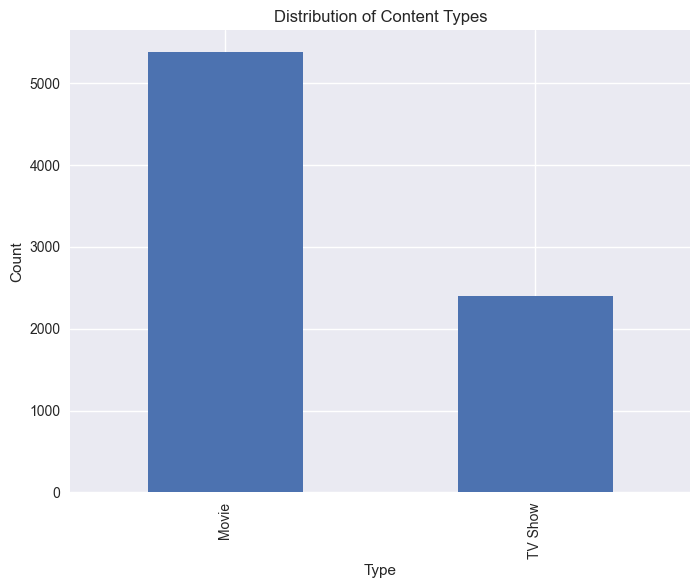

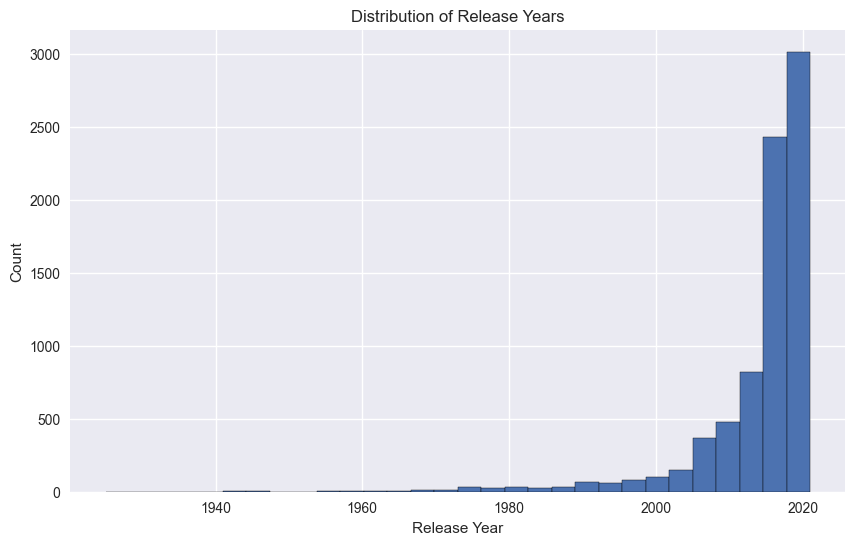

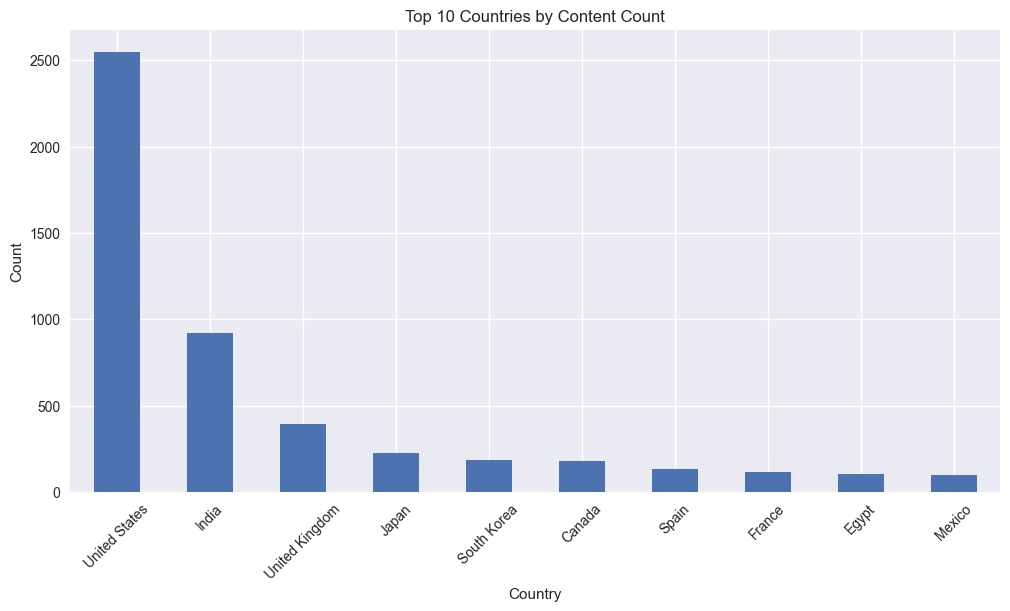

In [ ]:
# TODO: Create visualizations

# Content type distribution
plt.figure(figsize=(8, 6))
netflix_clean['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Content Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


# Release year histogram
if 'release_year' in netflix_clean.columns:
    plt.figure(figsize=(10, 6))
    netflix_clean['release_year'].hist(bins=30, edgecolor='black')
    plt.title('Distribution of Release Years')
    plt.xlabel('Release Year')
    plt.ylabel('Count')
    plt.show()

# Top countries bar chart
if 'country' in netflix_clean.columns:
    plt.figure(figsize=(12, 6))
    top_countries = netflix_clean['country'].value_counts().head(10)
    top_countries.plot(kind='bar')
    plt.title('Top 10 Countries by Content Count')
    plt.xlabel('Country')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


## Section 7: Summary Statistics and Conclusions

TODO: Generate comprehensive summary statistics and write your conclusions about the Netflix dataset. What insights can you draw from your analysis?


In [24]:
# TODO: Summary statistics and conclusions

# Generate summary statistics
print("Summary Statistics:")
print(netflix_clean.describe(include='all'))

# Additional insights
print("\nKey Insights:")
print(f"Total content: {len(netflix_clean)}")
print(f"Movies: {len(netflix_clean[netflix_clean['type'] == 'Movie'])}")
print(f"TV Shows: {len(netflix_clean[netflix_clean['type'] == 'TV Show'])}")

if 'release_year' in netflix_clean.columns:
    print(f"Oldest content: {netflix_clean['release_year'].min()}")
    print(f"Newest content: {netflix_clean['release_year'].max()}")



Summary Statistics:
         title   type  release_year        country rating  duration  \
count     7777   7777   7777.000000           7271   7770      7777   
unique    7777      2           NaN            681     14       216   
top     #Alive  Movie           NaN  United States  TV-MA  1 Season   
freq         1   5377           NaN           2549   2861      1608   
mean       NaN    NaN   2013.935965            NaN    NaN       NaN   
std        NaN    NaN      8.760694            NaN    NaN       NaN   
min        NaN    NaN   1925.000000            NaN    NaN       NaN   
25%        NaN    NaN   2013.000000            NaN    NaN       NaN   
50%        NaN    NaN   2017.000000            NaN    NaN       NaN   
75%        NaN    NaN   2018.000000            NaN    NaN       NaN   
max        NaN    NaN   2021.000000            NaN    NaN       NaN   

               imdb rotten_tomatoes target_age_bracket  
count   3247.000000            1276               1714  
unique       

In [25]:
# TODO: Write your conclusions here
"""
Conclusions:
[Your analysis and insights go here]
"""

'\nConclusions:\n[Your analysis and insights go here]\n'